In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.utils import *
from src.Cluster import Cluster
from src.KMeans import KMeans
from src.GMM import GMM
from src.DBSCAN import DBSCAN

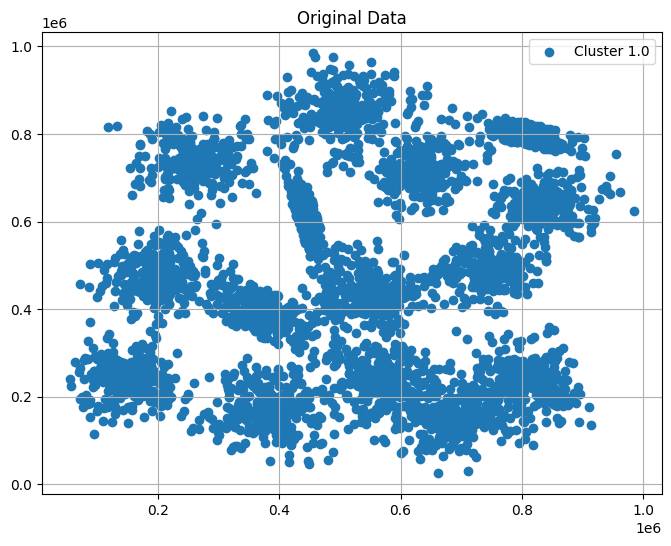

In [12]:
X = pd.read_csv('data/clustering.csv').drop(columns=['Unnamed: 0']).values
plot_clusters(X, np.ones(X.shape[0]), title="Original Data")

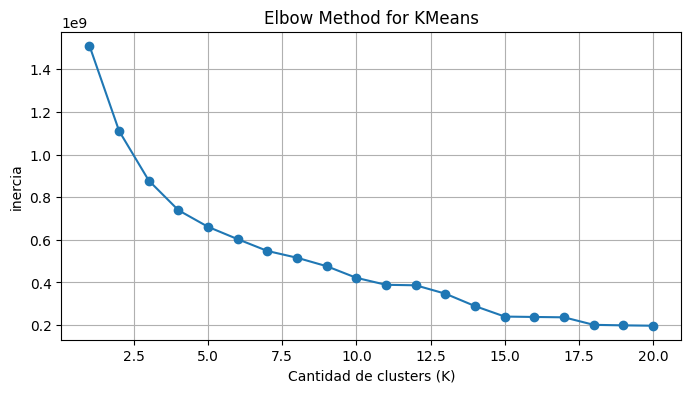

In [13]:
losses = elbow_method(X, range(1, 21), KMeans, random_state=42)
_ = plot_elbow(losses, range(1, 21), title="Elbow Method for KMeans")

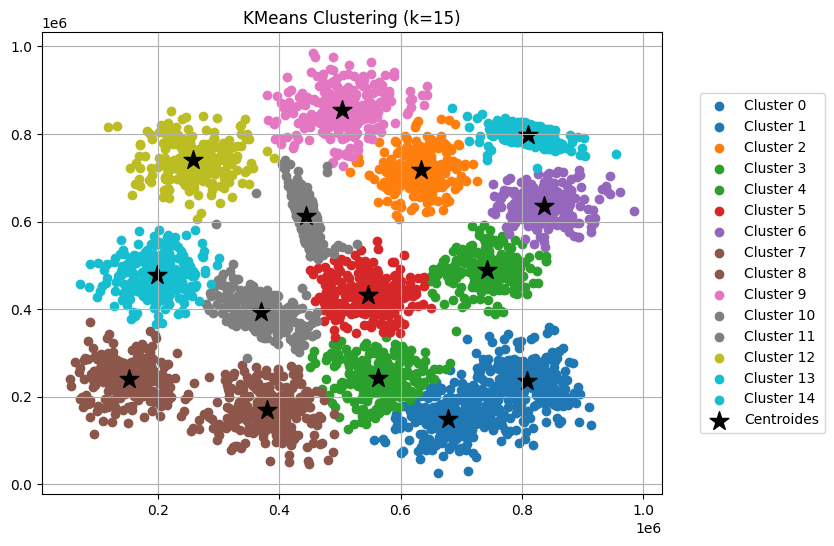

In [ ]:
k_opt = 15
random_seed = fit_random_seed(KMeans, X, k_opt)
kmeans = KMeans(n_clusters=k_opt, random_state=random_seed)
kmeans.fit(X)
plot_clusters(X, kmeans.predict(X), centroids=kmeans.means_, title=f"KMeans Clustering (k={k_opt})")

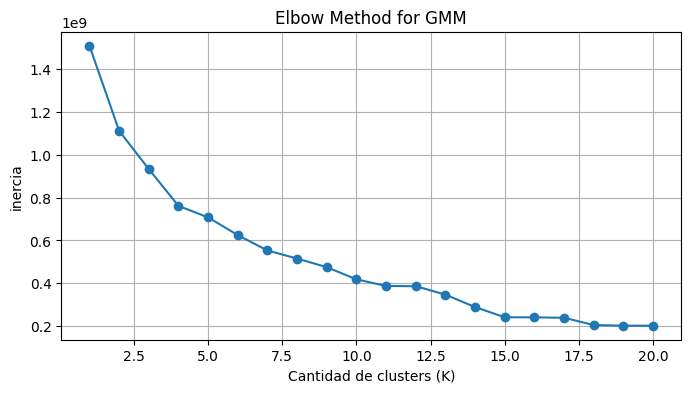

In [21]:
losses = elbow_method(X, range(1, 21), GMM, random_state=42)
_ = plot_elbow(losses, range(1, 21), title="Elbow Method for GMM")

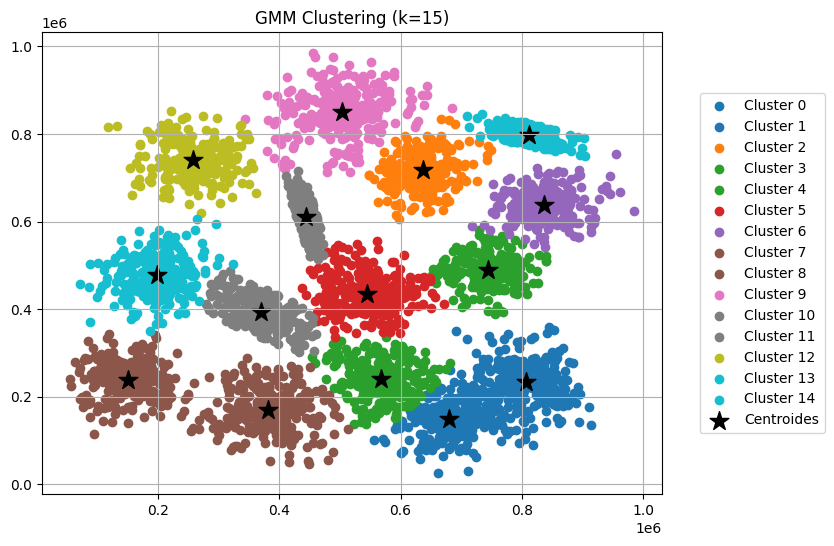

In [22]:
gmm = GMM(n_clusters=k_opt, random_state=random_seed)
gmm.fit(X)
plot_clusters(X, gmm.predict(X), centroids=gmm.means_, title=f"GMM Clustering (k={k_opt})")

Evaluando DBSCAN...: 100%|██████████| 9/9 [00:15<00:00,  1.70s/it]

Mejores parámetros: eps=20000, min_samples=15 con silhouette=0.590


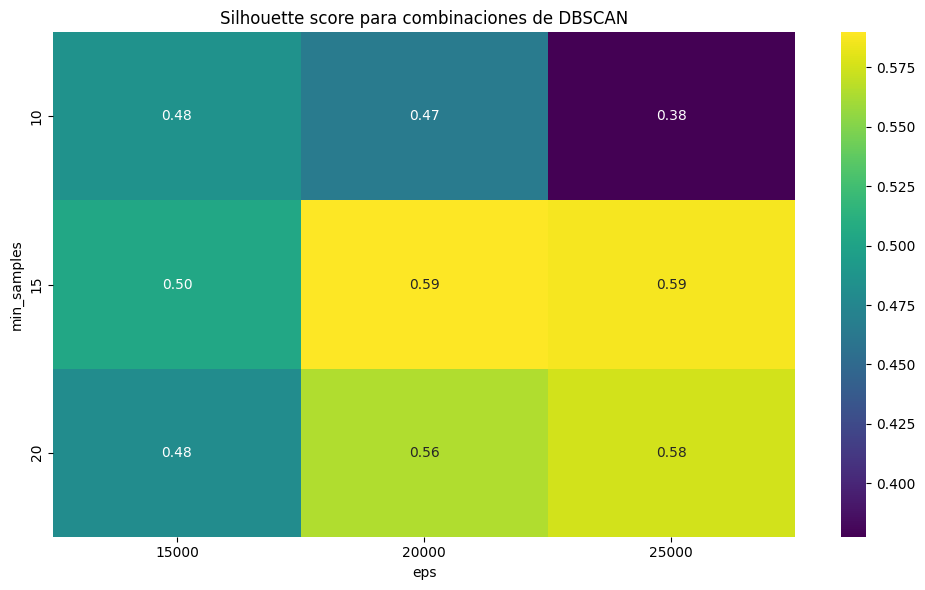

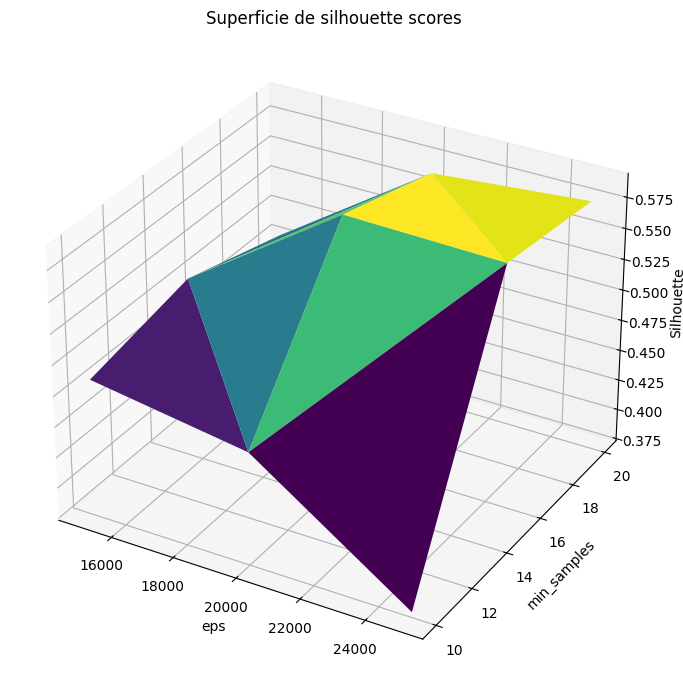

In [33]:
%reload_ext autoreload
scores, best_params = explore_dbscan_params(X,[15000, 20000, 25000], [10, 15, 20])
plot_dbscan_scores(scores)

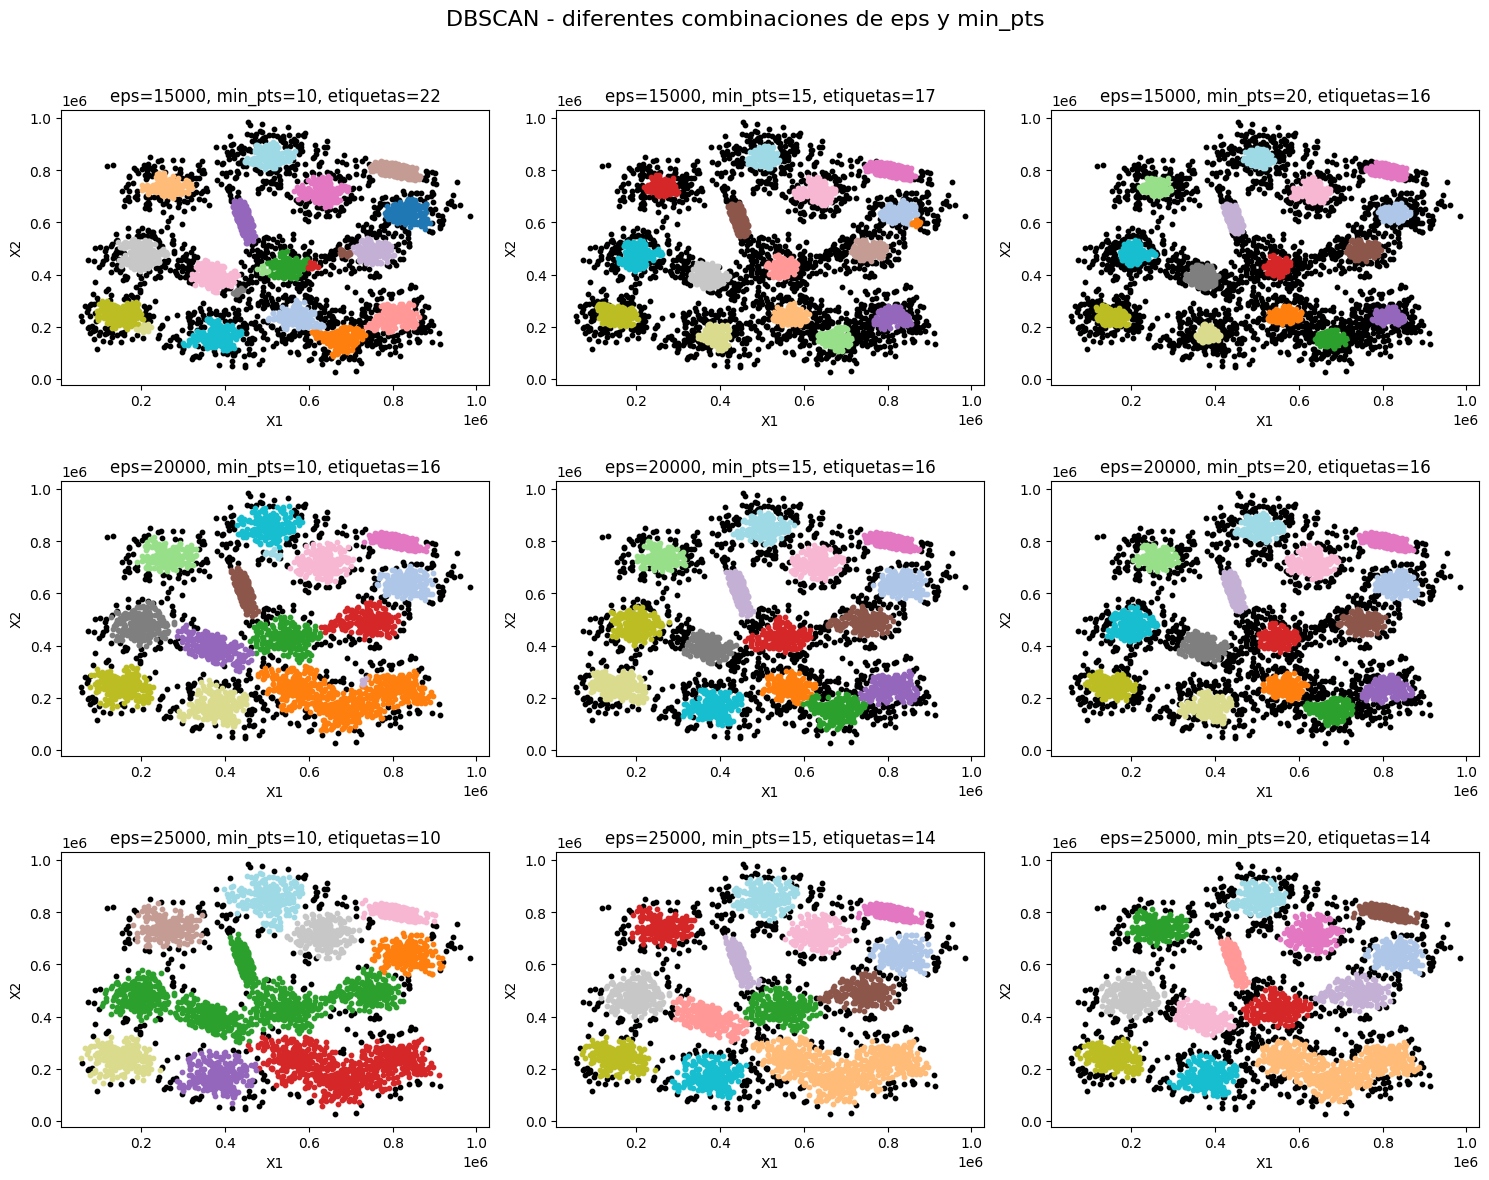

In [34]:
# Definir valores a probar
eps_values = [15000, 20000, 25000]
min_pts_values = [10, 15, 20]

# Crear grilla de gráficos
fig, axs = plt.subplots(len(eps_values), len(min_pts_values), figsize=(15, 12))
fig.suptitle("DBSCAN - diferentes combinaciones de eps y min_pts", fontsize=16)

for i, eps in enumerate(eps_values):
    for j, min_pts in enumerate(min_pts_values):
        model = DBSCAN(eps, min_pts)
        model.fit(X)
        etiquetas = model.labels_
        ax = axs[i, j]
        etiquetas_unicas = np.unique(etiquetas)
        colores = plt.cm.tab20(np.linspace(0, 1, len(etiquetas_unicas)))
        for k, etiqueta in enumerate(etiquetas_unicas):
            puntos = X[etiquetas == etiqueta]
            color = 'black' if etiqueta == -1 else colores[k % len(colores)]
            ax.scatter(puntos[:, 0], puntos[:, 1], color=color, s=10)
        ax.set_title(f"eps={eps}, min_pts={min_pts}, etiquetas={len(etiquetas_unicas)}")
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

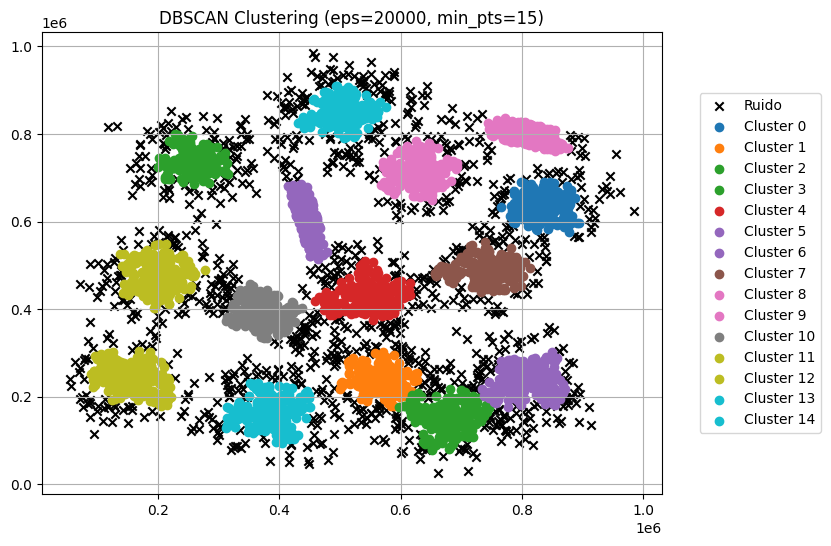

In [35]:
model = DBSCAN(best_params[0], best_params[1])
model.fit(X)
plot_clusters(X, model.labels_, title=f"DBSCAN Clustering (eps={best_params[0]}, min_pts={best_params[1]})")